In [1]:
import numpy as np
import matplotlib.pyplot as plt

In [2]:
import warnings
warnings.filterwarnings('ignore') 

import os
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '3'

import tensorflow as tf
tf.get_logger().setLevel('ERROR')

In [3]:
train_data_path = "seg_train/seg_train/"
test_data_path =  "seg_test/seg_test/"

In [4]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

In [5]:
datagen = ImageDataGenerator(rescale = 1/255)

In [38]:
train_datagen = datagen.flow_from_directory(train_data_path,target_size=(64,64),batch_size=25,class_mode='input')
test_datagen = datagen.flow_from_directory(test_data_path,target_size=(64,64),batch_size=25,class_mode='input')

Found 14034 images belonging to 6 classes.
Found 3000 images belonging to 6 classes.


In [39]:
batch1 = next(train_datagen)

In [40]:
type(batch1)

tuple

In [41]:
len(batch1)

2

In [42]:
batch1[0].shape

(25, 64, 64, 3)

In [53]:
14034/25

561.36

In [43]:
batch1[1].shape

(25, 64, 64, 3)

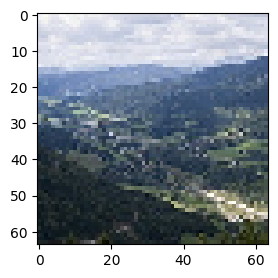

In [44]:
plt.figure(figsize=(3,3))
plt.imshow(batch1[0][2])
plt.show()

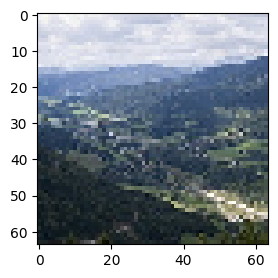

In [45]:
plt.figure(figsize=(3,3))
plt.imshow(batch1[1][2])
plt.show()

In [14]:
import tensorflow as tf
from tensorflow.keras.preprocessing import image
from tensorflow.keras.models import Model, Sequential
from tensorflow.keras.layers import Conv2D, MaxPool2D,Conv2DTranspose, Dropout, BatchNormalization,UpSampling2D

In [15]:
from keras_cv.layers import Grayscale

Using TensorFlow backend


In [46]:
gray_scale_layer = Grayscale()

In [47]:
gray = gray_scale_layer(batch1[0][0:5])

In [48]:
gray.shape

TensorShape([5, 64, 64, 1])

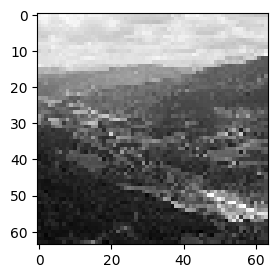

In [49]:
plt.figure(figsize=(3,3))
plt.imshow(gray[2],cmap='gray')
plt.show()

In [20]:
encoder = Sequential()
encoder.add(Conv2D(64,kernel_size=(3,3),strides=(1,1),padding='same',input_shape=(64,64,1)))
encoder.add(MaxPool2D())
encoder.add(Conv2D(128,kernel_size=(3,3),strides=(1,1),padding='same'))
encoder.add(MaxPool2D())
encoder.add(Conv2D(256,kernel_size=(3,3),strides=(1,1),padding='same'))
encoder.add(MaxPool2D())
encoder.add(Conv2D(512,kernel_size=(3,3),strides=(1,1),padding='same'))


decoder = Sequential()
decoder.add(Conv2DTranspose(256, (2, 2), strides=(2, 2), padding='same', activation='relu'))
decoder.add(Conv2DTranspose(128, (2, 2), strides=(2, 2), padding='same', activation='relu'))
decoder.add(Conv2DTranspose(64, (2, 2), strides=(2, 2), padding='same', activation='relu'))
decoder.add(BatchNormalization())
decoder.add(Conv2DTranspose(3, (1, 1), strides=(1, 1), padding='same', activation='sigmoid'))

autoencoder = Sequential()
autoencoder.add(Grayscale(input_shape=(64,64,3)))
autoencoder.add(encoder)
autoencoder.add(decoder)

In [21]:
encoder.summary()

Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 conv2d (Conv2D)             (None, 64, 64, 64)        640       
                                                                 
 max_pooling2d (MaxPooling2  (None, 32, 32, 64)        0         
 D)                                                              
                                                                 
 conv2d_1 (Conv2D)           (None, 32, 32, 128)       73856     
                                                                 
 max_pooling2d_1 (MaxPoolin  (None, 16, 16, 128)       0         
 g2D)                                                            
                                                                 
 conv2d_2 (Conv2D)           (None, 16, 16, 256)       295168    
                                                                 
 max_pooling2d_2 (MaxPoolin  (None, 8, 8, 256)         0

In [22]:
decoder.summary()

Model: "sequential_1"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 conv2d_transpose (Conv2DTr  (None, 16, 16, 256)       524544    
 anspose)                                                        
                                                                 
 conv2d_transpose_1 (Conv2D  (None, 32, 32, 128)       131200    
 Transpose)                                                      
                                                                 
 conv2d_transpose_2 (Conv2D  (None, 64, 64, 64)        32832     
 Transpose)                                                      
                                                                 
 batch_normalization (Batch  (None, 64, 64, 64)        256       
 Normalization)                                                  
                                                                 
 conv2d_transpose_3 (Conv2D  (None, 64, 64, 3)        

In [23]:
autoencoder.summary()

Model: "sequential_2"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 grayscale_1 (Grayscale)     (None, 64, 64, 1)         0         
                                                                 
 sequential (Sequential)     (None, 8, 8, 512)         1549824   
                                                                 
 sequential_1 (Sequential)   (None, 64, 64, 3)         689027    
                                                                 
Total params: 2238851 (8.54 MB)
Trainable params: 2238723 (8.54 MB)
Non-trainable params: 128 (512.00 Byte)
_________________________________________________________________


In [50]:
opt = tf.keras.optimizers.Adam(0.001)
loss = tf.keras.losses.MeanAbsoluteError()
autoencoder.compile(optimizer=opt,loss=loss)

In [25]:
autoencoder.fit(train_datagen,validation_data=(test_datagen),steps_per_epoch=561,epochs=50,verbose=2)

Epoch 1/50


I0000 00:00:1709318935.903222    1986 device_compiler.h:186] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


281/281 - 30s - loss: 0.1153 - val_loss: 0.1114 - 30s/epoch - 107ms/step
Epoch 2/50
281/281 - 26s - loss: 0.1004 - val_loss: 0.0954 - 26s/epoch - 92ms/step
Epoch 3/50
281/281 - 24s - loss: 0.0954 - val_loss: 0.0922 - 24s/epoch - 87ms/step
Epoch 4/50
281/281 - 28s - loss: 0.0915 - val_loss: 0.0925 - 28s/epoch - 100ms/step
Epoch 5/50
281/281 - 30s - loss: 0.0889 - val_loss: 0.0854 - 30s/epoch - 105ms/step
Epoch 6/50
281/281 - 28s - loss: 0.0877 - val_loss: 0.0842 - 28s/epoch - 98ms/step
Epoch 7/50
281/281 - 27s - loss: 0.0846 - val_loss: 0.0858 - 27s/epoch - 97ms/step
Epoch 8/50
281/281 - 27s - loss: 0.0833 - val_loss: 0.0865 - 27s/epoch - 95ms/step
Epoch 9/50
281/281 - 26s - loss: 0.0826 - val_loss: 0.0835 - 26s/epoch - 93ms/step
Epoch 10/50
281/281 - 27s - loss: 0.0814 - val_loss: 0.0825 - 27s/epoch - 97ms/step
Epoch 11/50
281/281 - 26s - loss: 0.0811 - val_loss: 0.0813 - 26s/epoch - 94ms/step
Epoch 12/50
281/281 - 25s - loss: 0.0808 - val_loss: 0.0789 - 25s/epoch - 89ms/step
Epoch 13/

In [26]:
from glob import glob
import cv2

In [54]:
img_path = glob("seg_test/seg_test/*/*.jpg")
img_path = img_path[:200]

color_img = []
gray_img = []

for path in img_path:
  img_bgr = cv2.resize(cv2.imread(path),(64,64))
  # convert bgr to rgb
  img = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)
  color_img.append(img)

  img = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2GRAY)
  gray_img.append(img)



color_img = np.array(color_img) / 255
gray_img = np.array(gray_img) / 255



In [55]:
pred_img = decoder.predict(encoder.predict(gray_img))

7/7 [==============================] - 0s 5ms/step


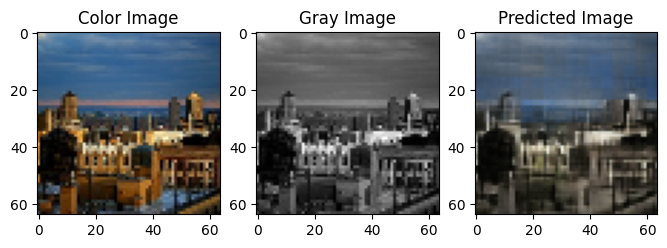

In [29]:
plt.figure(figsize=(8, 4))

plt.subplot(1, 3, 1)
plt.imshow(color_img[10])
plt.title('Color Image')

plt.subplot(1, 3, 2)
plt.imshow(gray_img[10], cmap='gray')
plt.title('Gray Image')

plt.subplot(1, 3, 3)
plt.imshow(pred_img[10])
plt.title('Predicted Image')

plt.show()